# 🎬 Scalable Video Recommendation System
## Step 3: DIN 精排模型 — KuaiRec 版本

---
**KuaiRec 特有改进**:
- 标签: `watch_ratio >= 0.5` 而非评分
- 加入 `watch_ratio` 作为辅助回归任务（多任务学习）
- 视频特征包含类别 + 每日统计特征（57列）

**本 Notebook 完成**:
```
Cell 1  → 安装依赖
Cell 2  → 配置 & 加载 Step 1/2 产出
Cell 3  → 特征预处理 & Dataset 封装
Cell 4  → DIN 模型定义（多任务：CTR + 时长预估）
Cell 5  → 训练循环（含 Early Stopping）
Cell 6  → 训练过程可视化
Cell 7  → 离线评估（AUC / GAUC / NDCG）
Cell 8  → 完整推荐链路测试（召回 → 精排 → Top10）
Cell 9  → 模型保存
Cell 10 → Step 3 完成报告
```

> 💡 **建议开启 GPU**: 运行时 → 更改运行时类型 → T4 GPU

---
## Cell 1 — 安装依赖

In [ ]:
!pip install -q torch torchvision faiss-cpu pyarrow pandas numpy scikit-learn tqdm tabulate matplotlib
print('✅ 依赖安装完成')

---
## Cell 2 — 配置 & 加载数据

In [1]:
import os, time, logging, warnings, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')

BASE_DIR = r'\workplace\dataset'

PATHS = {
    'features'     : f'{BASE_DIR}/data/features',
    'samples'      : f'{BASE_DIR}/data/samples',
    'feature_store': f'{BASE_DIR}/feature_store',
    'recall_models': f'{BASE_DIR}/models/recall',
    'rank_models'  : f'{BASE_DIR}/models/ranking',
    'reports'      : f'{BASE_DIR}/reports',
}
for p in PATHS.values(): os.makedirs(p, exist_ok=True)

CFG = {
    'embedding_dim'   : 32,
    'attention_hidden': [64, 16],
    'dnn_hidden'      : [256, 128, 64],
    'dropout'         : 0.3,
    'lr'              : 5e-4,
    'batch_size'      : 2048,
    'epochs'          : 30,
    'early_stop'      : 4,
    'seq_len'         : 50,
    'tower_emb_dim'   : 64,      # Step2 Embedding 维度
    'watch_ratio_max' : 3.0,     # watch_ratio clip 上限
    'multitask_alpha' : 0.5,     # 多任务权重: α*CTR + (1-α)*时长回归
    'random_seed'     : 42,
    'device'          : 'cuda' if torch.cuda.is_available() else 'cpu',
}
torch.manual_seed(CFG['random_seed'])
np.random.seed(CFG['random_seed'])

def get_logger():
    logger = logging.getLogger('Step3')
    logger.setLevel(logging.INFO)
    if logger.handlers: logger.handlers.clear()
    ch = logging.StreamHandler()
    ch.setFormatter(logging.Formatter('[%(asctime)s] %(message)s', '%H:%M:%S'))
    logger.addHandler(ch)
    return logger
log = get_logger()

class Timer:
    def __init__(self, name): self.name = name
    def __enter__(self): self.t = time.time(); log.info(f'▶ {self.name}'); return self
    def __exit__(self, *a): log.info(f'✅ {self.name} 完成  {time.time()-self.t:.1f}s')

with Timer('加载数据'):
    train_df    = pd.read_parquet(f"{PATHS['samples']}/train.parquet")
    test_df     = pd.read_parquet(f"{PATHS['samples']}/test.parquet")
    user_feat   = pd.read_parquet(f"{PATHS['features']}/user_features.parquet")
    item_feat   = pd.read_parquet(f"{PATHS['features']}/item_features.parquet")
    seq_df      = pd.read_parquet(f"{PATHS['features']}/user_sequences.parquet")
    user_emb_df = pd.read_parquet(f"{PATHS['feature_store']}/user_embeddings.parquet")
    item_emb_df = pd.read_parquet(f"{PATHS['feature_store']}/item_embeddings.parquet")
    with open(f"{PATHS['recall_models']}/id_mappings.pkl", 'rb') as f:
        id_maps  = pickle.load(f)
    user2idx = id_maps['user2idx']
    item2idx = id_maps['item2idx']
    idx2item = id_maps['idx2item']

log.info(f'训练集: {len(train_df):,}  测试集: {len(test_df):,}')
log.info(f'用户数: {user_feat.shape[0]:,}  视频数: {item_feat.shape[0]:,}')
log.info(f'设备: {CFG["device"]}')

[17:34:03] ▶ 加载数据
[17:34:04] ✅ 加载数据 完成  1.0s
[17:34:04] 训练集: 5,164,016  测试集: 934,735
[17:34:04] 用户数: 1,411  视频数: 3,327
[17:34:04] 设备: cuda


---
## Cell 3 — 特征预处理 & Dataset 封装

In [2]:
from sklearn.preprocessing import MinMaxScaler

USER_FEAT_COLS = [c for c in user_feat.columns
                  if c != 'user_id' and user_feat[c].dtype in
                  [np.float64, np.float32, np.int64, np.int32]]
ITEM_FEAT_COLS = [c for c in item_feat.columns
                  if c != 'item_id' and item_feat[c].dtype in
                  [np.float64, np.float32, np.int64, np.int32]]

user_scaler  = MinMaxScaler()
item_scaler  = MinMaxScaler()
user_feat_np = user_scaler.fit_transform(
    user_feat[USER_FEAT_COLS].fillna(0).values.astype(np.float32))
item_feat_np = item_scaler.fit_transform(
    item_feat[ITEM_FEAT_COLS].fillna(0).values.astype(np.float32))

user_feat_dict = {uid: user_feat_np[i] for i, uid in enumerate(user_feat['user_id'])}
item_feat_dict = {iid: item_feat_np[i] for i, iid in enumerate(item_feat['item_id'])}

EMB_COLS_U   = [c for c in user_emb_df.columns if c.startswith('user_emb_')]
EMB_COLS_I   = [c for c in item_emb_df.columns if c.startswith('item_emb_')]
user_emb_dict = {row['user_id']: row[EMB_COLS_U].values.astype(np.float32)
                 for _, row in user_emb_df.iterrows()}
item_emb_dict = {row['item_id']: row[EMB_COLS_I].values.astype(np.float32)
                 for _, row in item_emb_df.iterrows()}

seq_dict = {}
for _, row in seq_df.iterrows():
    raw = str(row.get('pos_seq', '') or '')
    ids = [item2idx[int(x)] for x in raw.split(',') if x and int(x) in item2idx]
    seq_dict[row['user_id']] = ids

U_DIM   = len(USER_FEAT_COLS)
I_DIM   = len(ITEM_FEAT_COLS)
EMB_DIM = len(EMB_COLS_U)
N_ITEMS = len(item2idx)
log.info(f'用户特征: {U_DIM}维  视频特征: {I_DIM}维  Embedding: {EMB_DIM}维')

[17:34:16] 用户特征: 31维  视频特征: 57维  Embedding: 64维


In [3]:
class DINDataset(Dataset):
    """
    KuaiRec 版 DIN Dataset
    多任务标签:
        label:       二值 CTR 标签（watch_ratio >= 0.5）
        watch_ratio: 连续值，用于时长回归任务
    """
    def __init__(self, df, user_feat_dict, item_feat_dict,
                 user_emb_dict, item_emb_dict,
                 seq_dict, item2idx, seq_len=50, watch_ratio_max=3.0):
        self.df              = df.reset_index(drop=True)
        self.u_feat          = user_feat_dict
        self.i_feat          = item_feat_dict
        self.u_emb           = user_emb_dict
        self.i_emb           = item_emb_dict
        self.seq_dict        = seq_dict
        self.item2idx        = item2idx
        self.seq_len         = seq_len
        self.watch_ratio_max = watch_ratio_max
        self.u_dim           = len(next(iter(user_feat_dict.values())))
        self.i_dim           = len(next(iter(item_feat_dict.values())))
        self.emb_dim         = len(next(iter(user_emb_dict.values())))

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row         = self.df.iloc[idx]
        uid         = row['user_id']
        iid         = row['item_id']
        label       = float(row['label'])
        # watch_ratio 归一化到 [0,1]，作为回归目标
        watch_ratio = float(min(row.get('watch_ratio', 0.0), self.watch_ratio_max))
        watch_ratio_norm = watch_ratio / self.watch_ratio_max

        u_vec = self.u_feat.get(uid, np.zeros(self.u_dim,  np.float32))
        u_emb = self.u_emb.get(uid, np.zeros(self.emb_dim, np.float32))
        i_vec = self.i_feat.get(iid, np.zeros(self.i_dim,  np.float32))
        i_emb = self.i_emb.get(iid, np.zeros(self.emb_dim, np.float32))

        seq      = self.seq_dict.get(uid, [])
        seq      = seq[-self.seq_len:]
        pad_len  = self.seq_len - len(seq)
        seq_pad  = torch.tensor([0]*pad_len + seq, dtype=torch.long)
        seq_mask = torch.tensor([0]*pad_len + [1]*len(seq), dtype=torch.float)

        return (
            torch.tensor(u_vec,           dtype=torch.float),
            torch.tensor(u_emb,           dtype=torch.float),
            torch.tensor(i_vec,           dtype=torch.float),
            torch.tensor(i_emb,           dtype=torch.float),
            seq_pad,
            seq_mask,
            torch.tensor(label,           dtype=torch.float),
            torch.tensor(watch_ratio_norm, dtype=torch.float),
        )

train_ds = DINDataset(train_df, user_feat_dict, item_feat_dict,
                      user_emb_dict, item_emb_dict,
                      seq_dict, item2idx, CFG['seq_len'], CFG['watch_ratio_max'])
test_ds  = DINDataset(test_df,  user_feat_dict, item_feat_dict,
                      user_emb_dict, item_emb_dict,
                      seq_dict, item2idx, CFG['seq_len'], CFG['watch_ratio_max'])

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                          shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=2, pin_memory=True)

log.info(f'训练集: {len(train_ds):,}  测试集: {len(test_ds):,}')

[17:34:25] 训练集: 5,164,016  测试集: 934,735


---
## Cell 4 — DIN 模型定义（多任务：CTR + 时长预估）

In [4]:
# ============================================================
# KuaiRec 版 DIN：多任务学习
#
# 任务1: CTR 预估（二分类）
#   → watch_ratio >= 0.5 = 正样本
#
# 任务2: 时长预估（回归）
#   → 预测 watch_ratio 归一化值
#   → 对应企业: 快手/抖音的「完播率预估」
#
# 最终排序分数 = α * CTR分 + (1-α) * 完播率分
# ============================================================

class DINAttention(nn.Module):
    """DIN 注意力：目标视频 × 历史行为序列"""
    def __init__(self, emb_dim, hidden=[64, 16]):
        super().__init__()
        dims   = [emb_dim * 4] + hidden + [1]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)

    def forward(self, target_emb, seq_emb, mask):
        B, L, D   = seq_emb.shape
        t_exp     = target_emb.unsqueeze(1).expand(-1, L, -1)
        concat    = torch.cat([t_exp, seq_emb,
                               t_exp - seq_emb,
                               t_exp * seq_emb], dim=-1)
        scores    = self.net(concat).squeeze(-1)
        scores    = scores - (1 - mask) * 1e9
        weights   = torch.softmax(scores, dim=-1)
        return (weights.unsqueeze(-1) * seq_emb).sum(dim=1)


class DINMultiTask(nn.Module):
    """
    多任务 DIN
    共享底层 DNN + 两个独立输出头:
        ctr_head:      CTR 预估（sigmoid）
        duration_head: 完播率预估（sigmoid，输出 0~1）
    """
    def __init__(self, n_items, i_feat_dim, u_feat_dim, tower_emb_dim, cfg):
        super().__init__()
        emb_dim    = cfg['embedding_dim']
        att_hidden = cfg['attention_hidden']
        dnn_hidden = cfg['dnn_hidden']
        dropout    = cfg['dropout']

        # 序列 Embedding
        self.item_emb  = nn.Embedding(n_items + 1, emb_dim, padding_idx=0)
        # DIN 注意力
        self.attention = DINAttention(emb_dim, att_hidden)

        # DNN 输入维度
        dnn_input_dim = (u_feat_dim + tower_emb_dim +
                         i_feat_dim + tower_emb_dim + emb_dim)

        # 共享底层
        shared_layers = []
        dims = [dnn_input_dim] + dnn_hidden[:-1]
        for i in range(len(dims) - 1):
            shared_layers += [
                nn.Linear(dims[i], dims[i+1]),
                nn.BatchNorm1d(dims[i+1]),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
        self.shared_dnn = nn.Sequential(*shared_layers)

        # 两个独立 Tower
        last_dim = dnn_hidden[-2] if len(dnn_hidden) > 1 else dnn_input_dim
        tower_dim = dnn_hidden[-1]
        self.ctr_tower      = nn.Sequential(
            nn.Linear(last_dim, tower_dim), nn.ReLU(),
            nn.Linear(tower_dim, 1)
        )
        self.duration_tower = nn.Sequential(
            nn.Linear(last_dim, tower_dim), nn.ReLU(),
            nn.Linear(tower_dim, 1)
        )

    def forward(self, u_feat, u_emb, i_feat, i_emb, seq_idx, seq_mask):
        seq_emb  = self.item_emb(seq_idx)
        att_out  = self.attention(
            i_emb[:, :self.item_emb.embedding_dim], seq_emb, seq_mask)
        x        = torch.cat([u_feat, u_emb, i_feat, i_emb, att_out], dim=-1)
        shared   = self.shared_dnn(x)
        ctr_logit      = self.ctr_tower(shared).squeeze(-1)
        duration_logit = self.duration_tower(shared).squeeze(-1)
        return torch.sigmoid(ctr_logit), torch.sigmoid(duration_logit)


model = DINMultiTask(
    n_items       = N_ITEMS,
    i_feat_dim    = I_DIM,
    u_feat_dim    = U_DIM,
    tower_emb_dim = EMB_DIM,
    cfg           = CFG,
).to(CFG['device'])

total = sum(p.numel() for p in model.parameters())
log.info(f'DIN 多任务模型参数: {total:,}')
log.info(f'输入维度: {U_DIM}+{EMB_DIM}+{I_DIM}+{EMB_DIM}+{CFG["embedding_dim"]} = '
         f'{U_DIM+EMB_DIM+I_DIM+EMB_DIM+CFG["embedding_dim"]}')

[17:34:27] DIN 多任务模型参数: 229,859
[17:34:27] 输入维度: 31+64+57+64+32 = 248


---
## Cell 5 — 训练循环（多任务 Loss）

In [5]:
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

bce_loss = nn.BCELoss()
mse_loss = nn.MSELoss()

def multitask_loss(ctr_pred, dur_pred, ctr_label, dur_label, alpha):
    """
    多任务 Loss
    L = alpha * BCE(CTR) + (1-alpha) * MSE(完播率)
    """
    l_ctr = bce_loss(ctr_pred, ctr_label)
    l_dur = mse_loss(dur_pred, dur_label)
    return alpha * l_ctr + (1 - alpha) * l_dur, l_ctr.item(), l_dur.item()

optimizer = torch.optim.Adam(
    model.parameters(), lr=CFG['lr'], weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.5)

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0
    all_ctr_preds, all_ctr_labels = [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            u_feat, u_emb, i_feat, i_emb, seq, mask, ctr_label, dur_label = [
                b.to(CFG['device']) for b in batch]
            ctr_pred, dur_pred = model(u_feat, u_emb, i_feat, i_emb, seq, mask)
            loss, _, _ = multitask_loss(
                ctr_pred, dur_pred, ctr_label, dur_label, CFG['multitask_alpha'])
            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()
            all_ctr_preds.extend(ctr_pred.detach().cpu().numpy())
            all_ctr_labels.extend(ctr_label.cpu().numpy())
    avg_loss = total_loss / len(loader)
    auc = roc_auc_score(all_ctr_labels, all_ctr_preds) \
          if len(set(all_ctr_labels)) > 1 else 0.5
    return avg_loss, auc, all_ctr_preds, all_ctr_labels

history    = {'train_loss':[], 'val_loss':[], 'train_auc':[], 'val_auc':[]}
best_auc   = 0.0
no_improve = 0
CKPT_PATH  = f"{PATHS['rank_models']}/din_best.pt"

log.info(f'开始训练  epochs={CFG["epochs"]}  device={CFG["device"]}')
print()

for epoch in range(1, CFG['epochs'] + 1):
    t0 = time.time()
    tr_loss, tr_auc, _, _ = run_epoch(train_loader, training=True)
    va_loss, va_auc, _, _ = run_epoch(test_loader,  training=False)
    scheduler.step(va_auc)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_auc'].append(tr_auc)
    history['val_auc'].append(va_auc)

    flag = '⬆ best' if va_auc > best_auc else ''
    print(f'Epoch {epoch:3d}/{CFG["epochs"]}  '
          f'loss={tr_loss:.4f}/{va_loss:.4f}  '
          f'AUC={tr_auc:.4f}/{va_auc:.4f}  '
          f'{time.time()-t0:.1f}s  {flag}')

    if va_auc > best_auc:
        best_auc   = va_auc
        no_improve = 0
        torch.save({'epoch': epoch, 'model': model.state_dict(),
                    'val_auc': va_auc, 'cfg': CFG}, CKPT_PATH)
    else:
        no_improve += 1
        if no_improve >= CFG['early_stop']:
            log.info(f'Early stopping at epoch {epoch}')
            break

ckpt = torch.load(CKPT_PATH, map_location=CFG['device'], weights_only=False)
model.load_state_dict(ckpt['model'])
log.info(f'最佳模型  epoch={ckpt["epoch"]}  val_AUC={ckpt["val_auc"]:.4f}')

[17:34:33] 开始训练  epochs=30  device=cuda



Epoch   1/30  loss=0.2269/1.7248  AUC=0.8737/0.5986  842.6s  ⬆ best
Epoch   2/30  loss=0.2170/2.4458  AUC=0.8835/0.5632  849.4s  
Epoch   3/30  loss=0.2132/3.3352  AUC=0.8877/0.5459  841.1s  
Epoch   4/30  loss=0.2107/3.2806  AUC=0.8906/0.5669  845.6s  


[18:44:58] Early stopping at epoch 5
[18:44:58] 最佳模型  epoch=1  val_AUC=0.5986


Epoch   5/30  loss=0.2080/3.7671  AUC=0.8936/0.5521  846.4s  


---
## Cell 6 — 训练过程可视化

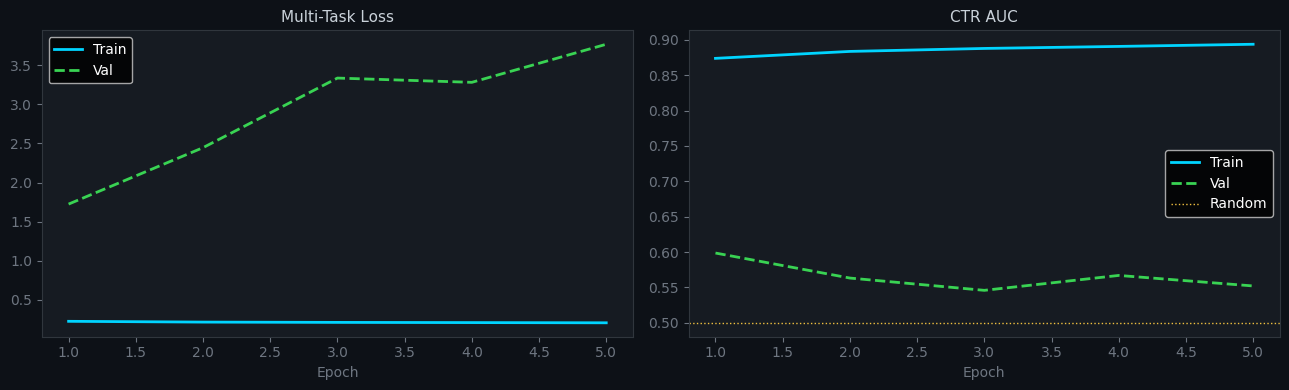

In [6]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0d1117')

def styled(ax, title):
    ax.set_facecolor('#161b22')
    ax.set_title(title, color='#c9d1d9', fontsize=11)
    ax.tick_params(colors='#6e7681')
    for s in ax.spines.values(): s.set_color('#30363d')

ep = range(1, len(history['train_loss']) + 1)
styled(axes[0], 'Multi-Task Loss')
axes[0].plot(ep, history['train_loss'], '#00d4ff', lw=2, label='Train')
axes[0].plot(ep, history['val_loss'],   '#39d353', lw=2, label='Val', linestyle='--')
axes[0].set_xlabel('Epoch', color='#6e7681')
axes[0].legend()

styled(axes[1], 'CTR AUC')
axes[1].plot(ep, history['train_auc'], '#00d4ff', lw=2, label='Train')
axes[1].plot(ep, history['val_auc'],   '#39d353', lw=2, label='Val', linestyle='--')
axes[1].axhline(y=0.5, color='#f0c040', linestyle=':', lw=1, label='Random')
axes[1].set_xlabel('Epoch', color='#6e7681')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{PATHS['reports']}/step3_training_curve.png",
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## Cell 7 — 离线评估（AUC / GAUC / NDCG）

In [7]:
from sklearn.metrics import roc_auc_score, log_loss, mean_squared_error
from tabulate import tabulate

def compute_gauc(df, preds, labels):
    df = df.copy()
    df['pred']  = preds
    df['label'] = labels
    gauc_sum, weight_sum = 0.0, 0
    for uid, group in df.groupby('user_id'):
        if group['label'].nunique() < 2: continue
        auc = roc_auc_score(group['label'], group['pred'])
        gauc_sum  += auc * len(group)
        weight_sum += len(group)
    return gauc_sum / weight_sum if weight_sum > 0 else 0

def compute_ndcg(df, preds, k=10):
    df = df.copy()
    df['pred'] = preds
    ndcg_list  = []
    for uid, group in df.groupby('user_id'):
        if group['label'].sum() == 0: continue
        group = group.sort_values('pred', ascending=False).head(k)
        dcg   = sum(row['label'] / np.log2(i+2)
                    for i, (_, row) in enumerate(group.iterrows()))
        idcg  = sum(1/np.log2(i+2)
                    for i in range(min(int(group['label'].sum()), k)))
        ndcg_list.append(dcg/idcg if idcg > 0 else 0)
    return np.mean(ndcg_list) if ndcg_list else 0

with Timer('离线评估'):
    _, _, all_ctr_preds, all_ctr_labels = run_epoch(test_loader, training=False)

    # 同时获取 watch_ratio 预测（用于 RMSE）
    model.eval()
    all_dur_preds, all_dur_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            u_feat, u_emb, i_feat, i_emb, seq, mask, _, dur_label = [
                b.to(CFG['device']) for b in batch]
            _, dur_pred = model(u_feat, u_emb, i_feat, i_emb, seq, mask)
            all_dur_preds.extend(dur_pred.detach().cpu().numpy())
            all_dur_labels.extend(dur_label.cpu().numpy())

    auc      = roc_auc_score(all_ctr_labels, all_ctr_preds)
    logloss  = log_loss(all_ctr_labels, all_ctr_preds)
    gauc     = compute_gauc(test_df.reset_index(drop=True), all_ctr_preds, all_ctr_labels)
    ndcg10   = compute_ndcg(test_df.reset_index(drop=True), all_ctr_preds, k=10)
    ndcg20   = compute_ndcg(test_df.reset_index(drop=True), all_ctr_preds, k=20)
    rmse_dur = float(np.sqrt(mean_squared_error(all_dur_labels, all_dur_preds)))

print('\n【DIN 多任务模型离线评估】')
rows = [
    ['CTR AUC',     f'{auc:.4f}',      '>0.72 达标',  'CTR 排序能力'],
    ['GAUC',        f'{gauc:.4f}',     '>0.68 达标',  '分用户AUC均值'],
    ['LogLoss',     f'{logloss:.4f}',  '<0.50 达标',  'CTR 校准度'],
    ['NDCG@10',     f'{ndcg10:.4f}',   '越高越好',    'Top10排序质量'],
    ['NDCG@20',     f'{ndcg20:.4f}',   '越高越好',    'Top20排序质量'],
    ['完播率 RMSE', f'{rmse_dur:.4f}', '越低越好',    '时长预估误差'],
]
print(tabulate(rows, headers=['指标', '数值', '参考标准', '说明'], tablefmt='grid'))

[18:58:10] ▶ 离线评估
[19:02:39] ✅ 离线评估 完成  268.2s



【DIN 多任务模型离线评估】
+-------------+--------+------------+---------------+
| 指标        |   数值 | 参考标准   | 说明          |
+=============+========+============+===============+
| CTR AUC     | 0.5986 | >0.72 达标 | CTR 排序能力  |
+-------------+--------+------------+---------------+
| GAUC        | 0.6058 | >0.68 达标 | 分用户AUC均值 |
+-------------+--------+------------+---------------+
| LogLoss     | 3.3697 | <0.50 达标 | CTR 校准度    |
+-------------+--------+------------+---------------+
| NDCG@10     | 0.9675 | 越高越好   | Top10排序质量 |
+-------------+--------+------------+---------------+
| NDCG@20     | 0.9677 | 越高越好   | Top20排序质量 |
+-------------+--------+------------+---------------+
| 完播率 RMSE | 0.2815 | 越低越好   | 时长预估误差  |
+-------------+--------+------------+---------------+


---
## Cell 8 — 完整推荐链路测试

In [8]:
import faiss

faiss_index     = faiss.read_index(f"{PATHS['recall_models']}/faiss_item.index")
recall_item_ids = np.load(f"{PATHS['recall_models']}/item_ids.npy")
recall_user_ids = np.load(f"{PATHS['recall_models']}/user_ids.npy")
user_id2row     = {uid: i for i, uid in enumerate(recall_user_ids)}

user_emb_matrix = np.stack([
    user_emb_dict.get(uid, np.zeros(EMB_DIM, np.float32))
    for uid in recall_user_ids
]).astype(np.float32)
faiss.normalize_L2(user_emb_matrix)


def recommend(user_id, recall_k=200, top_n=10, alpha=None):
    """
    完整推荐链路
    召回 → DIN精排（CTR + 完播率）→ Top N

    排序分数 = alpha * CTR + (1-alpha) * 完播率
    """
    if alpha is None: alpha = CFG['multitask_alpha']
    model.eval()
    device = CFG['device']

    if user_id not in user_id2row: return []
    u_vec = user_emb_matrix[user_id2row[user_id]:user_id2row[user_id]+1]
    _, indices    = faiss_index.search(u_vec, recall_k)
    candidate_ids = [int(recall_item_ids[i]) for i in indices[0]]

    u_feat_v = torch.tensor(
        user_feat_dict.get(user_id, np.zeros(U_DIM, np.float32)),
        dtype=torch.float).unsqueeze(0).to(device)
    u_emb_v  = torch.tensor(
        user_emb_dict.get(user_id, np.zeros(EMB_DIM, np.float32)),
        dtype=torch.float).unsqueeze(0).to(device)

    seq      = seq_dict.get(user_id, [])
    seq      = seq[-CFG['seq_len']:]
    pad_len  = CFG['seq_len'] - len(seq)
    seq_pad  = torch.tensor([0]*pad_len + seq, dtype=torch.long).unsqueeze(0).to(device)
    seq_mask = torch.tensor([0]*pad_len + [1]*len(seq), dtype=torch.float).unsqueeze(0).to(device)

    scores = []
    for start in range(0, len(candidate_ids), 64):
        batch_iids = candidate_ids[start:start+64]
        B = len(batch_iids)
        i_feat_b = torch.tensor(
            np.stack([item_feat_dict.get(i, np.zeros(I_DIM, np.float32)) for i in batch_iids]),
            dtype=torch.float).to(device)
        i_emb_b  = torch.tensor(
            np.stack([item_emb_dict.get(i, np.zeros(EMB_DIM, np.float32)) for i in batch_iids]),
            dtype=torch.float).to(device)
        with torch.no_grad():
            ctr_pred, dur_pred = model(
                u_feat_v.expand(B,-1), u_emb_v.expand(B,-1),
                i_feat_b, i_emb_b,
                seq_pad.expand(B,-1), seq_mask.expand(B,-1))
        # 融合分数
        final_score = alpha * ctr_pred + (1-alpha) * dur_pred
        scores.extend(zip(batch_iids,
                          ctr_pred.cpu().numpy(),
                          dur_pred.cpu().numpy(),
                          final_score.cpu().numpy()))

    scores.sort(key=lambda x: x[3], reverse=True)
    return scores[:top_n]


print('\n【完整推荐链路测试】')
print(f'  召回: 200候选  精排: Top10  分数=0.5*CTR+0.5*完播率\n')
test_users = list(user2idx.keys())[:3]
for uid in test_users:
    results = recommend(uid, recall_k=200, top_n=10)
    print(f'  用户 {uid}:')
    for rank, (iid, ctr, dur, score) in enumerate(results, 1):
        print(f'    #{rank:2d}  item={iid:5d}  CTR={ctr:.3f}  完播率={dur:.3f}  综合={score:.3f}')
    print()


【完整推荐链路测试】
  召回: 200候选  精排: Top10  分数=0.5*CTR+0.5*完播率

  用户 14:
    # 1  item=  314  CTR=0.946  完播率=0.679  综合=0.812
    # 2  item=  154  CTR=0.938  完播率=0.665  综合=0.802
    # 3  item= 8298  CTR=0.939  完播率=0.653  综合=0.796
    # 4  item= 4040  CTR=0.916  完播率=0.654  综合=0.785
    # 5  item= 5464  CTR=0.924  完播率=0.645  综合=0.784
    # 6  item= 6787  CTR=0.933  完播率=0.636  综合=0.784
    # 7  item= 8366  CTR=0.919  完播率=0.640  综合=0.780
    # 8  item= 8524  CTR=0.922  完播率=0.638  综合=0.780
    # 9  item= 2130  CTR=0.921  完播率=0.637  综合=0.779
    #10  item= 5525  CTR=0.919  完播率=0.639  综合=0.779

  用户 19:
    # 1  item=  314  CTR=0.959  完播率=0.688  综合=0.824
    # 2  item= 8298  CTR=0.965  完播率=0.674  综合=0.819
    # 3  item=  154  CTR=0.959  完播率=0.676  综合=0.818
    # 4  item= 5464  CTR=0.940  完播率=0.647  综合=0.794
    # 5  item= 6787  CTR=0.956  完播率=0.630  综合=0.793
    # 6  item= 5525  CTR=0.942  完播率=0.644  综合=0.793
    # 7  item= 8366  CTR=0.937  完播率=0.647  综合=0.792
    # 8  item= 2130  CTR=0.941  完播率=0.637

---
## Cell 9 — 模型保存

In [9]:
with Timer('保存模型'):
    torch.save({
        'epoch'    : ckpt['epoch'],
        'model'    : model.state_dict(),
        'val_auc'  : ckpt['val_auc'],
        'cfg'      : CFG,
        'u_dim'    : U_DIM,
        'i_dim'    : I_DIM,
        'emb_dim'  : EMB_DIM,
        'n_items'  : N_ITEMS,
    }, CKPT_PATH)
    with open(f"{PATHS['rank_models']}/scalers.pkl", 'wb') as f:
        pickle.dump({'user': user_scaler, 'item': item_scaler}, f)
log.info('✅ 模型保存完成')

[19:06:12] ▶ 保存模型
[19:06:12] ✅ 保存模型 完成  0.0s
[19:06:12] ✅ 模型保存完成


---
## Cell 10 — Step 3 完成报告

In [10]:
print('\n' + '='*65)
print('  📋  STEP 3 PIPELINE 完成报告（KuaiRec 版本）')
print('='*65)

summary = [
    ['数据集',      'KuaiRec small_matrix',                ''],
    ['模型',        'DIN 多任务（CTR + 完播率）',          ''],
    ['训练样本数',  f'{len(train_ds):,}',                  '条'],
    ['最佳 Epoch',  str(ckpt['epoch']),                    ''],
    ['CTR AUC',     f'{auc:.4f}',                          ''],
    ['GAUC',        f'{gauc:.4f}',                         ''],
    ['LogLoss',     f'{logloss:.4f}',                      ''],
    ['NDCG@10',     f'{ndcg10:.4f}',                       ''],
    ['完播率 RMSE', f'{rmse_dur:.4f}',                     ''],
]
print(tabulate(summary, headers=['指标', '数值', '单位'], tablefmt='simple'))

print('\n【输出文件】')
for fp in [
    f"{PATHS['rank_models']}/din_best.pt",
    f"{PATHS['rank_models']}/scalers.pkl",
    f"{PATHS['reports']}/step3_training_curve.png",
]:
    if os.path.exists(fp):
        mb = os.path.getsize(fp)/1024**2
        print(f'  ✅ {fp.replace(BASE_DIR+"/",""):50s} {mb:.2f} MB')
    else:
        print(f'  ❌ {fp}')

print('\n' + '='*65)
print('  ✅  Step 3 完成！')
print('  ▶   下一步: Step 4 — A/B 实验平台 + 在线监控')
print('='*65)


  📋  STEP 3 PIPELINE 完成报告（KuaiRec 版本）
指标         数值                        单位
-----------  --------------------------  ------
数据集       KuaiRec small_matrix
模型         DIN 多任务（CTR + 完播率）
训练样本数   5,164,016                   条
最佳 Epoch   1
CTR AUC      0.5986
GAUC         0.6058
LogLoss      3.3697
NDCG@10      0.9675
完播率 RMSE  0.2815

【输出文件】
  ✅ models/ranking/din_best.pt                         0.89 MB
  ✅ models/ranking/scalers.pkl                         0.00 MB
  ✅ reports/step3_training_curve.png                   0.06 MB

  ✅  Step 3 完成！
  ▶   下一步: Step 4 — A/B 实验平台 + 在线监控
